| Device(s)                   | Change type                | Column(s) affected                                                                              | Exact change                                                                                                      |
| --------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **All 24 datasets**         | Row removal                | All columns                                                                                     | First **4 months of telemetry** removed, based on each dataset's earliest timestamp.                              |
| **ULC10**                   | Polarity correction        | `L2ActivePower_W`                                                                               | Values multiplied by `-1`.                                                                                        |
| **ULC10**                   | Three-phase reconstruction | `ActiveThreePhasePower_W`                                                                       | Rebuilt as `L1ActivePower_W + L2ActivePower_W + L3ActivePower_W` after the L2 polarity correction.                |
| **ULC10**                   | Polarity correction        | `L2ApparentPower_VA`                                                                            | Values multiplied by `-1`.                                                                                        |
| **ULC10**                   | Three-phase reconstruction | `ApparentThreePhasePower_VA`                                                                    | Rebuilt as `L1ApparentPower_VA + L2ApparentPower_VA + L3ApparentPower_VA`.                                        |
| **ULC10**                   | Polarity correction        | `L2CapacitivePower_var`                                                                         | Values multiplied by `-1`.                                                                                        |
| **ULC10**                   | Three-phase reconstruction | `CapacitiveThreePhasePower_var`                                                                 | Rebuilt as `L1CapacitivePower_var + L2CapacitivePower_var + L3CapacitivePower_var`.                               |
| **ULC12**                   | Polarity correction        | `L2ActivePower_W`                                                                               | Values multiplied by `-1`.                                                                                        |
| **ULC12**                   | Three-phase reconstruction | `ActiveThreePhasePower_W`                                                                       | Rebuilt as `L1ActivePower_W + L2ActivePower_W + L3ActivePower_W`.                                                 |
| **ULC12**                   | Row removal                | `L2ApparentPower_VA`, `L2CapacitivePower_var`                                                   | Entire rows removed where either column contains a negative value.                                                |
| **CRAC2**                   | Row removal                | `L3ActivePower_W`, `L3ApparentPower_VA`, `L3InductivePower_var`, `InductiveThreePhasePower_var` | Entire rows removed where any configured column contains a negative value.                                        |
| **CRAC5**                   | Row removal                | `L2ActivePower_W`, `L2InductivePower_var`, `L2ApparentPower_VA`, `InductiveThreePhasePower_var` | Entire rows removed where any configured column contains a negative value.                                        |
| **CRAC6**                   | Row removal                | `L3ActivePower_W`, `L3InductivePower_var`, `L3ApparentPower_VA`                                 | Entire rows removed where any configured column contains a negative value.                                        |
| **All applicable datasets** | New derived columns        | `DerivedConsumedActiveEnergy_kWh`                                                               | Added from `ActiveThreePhasePower_W` using trapezoidal integration; original cumulative-energy counters retained. |
| **All applicable datasets** | New derived columns        | `DerivedConsumedApparentEnergy_kVAh`                                                            | Added from `ApparentThreePhasePower_VA` using trapezoidal integration.                                            |
| **All applicable datasets** | New derived columns        | `DerivedConsumedCapacitiveReactiveEnergy_kvarh`                                                 | Added from `CapacitiveThreePhasePower_var` using trapezoidal integration.                                         |
| **All applicable datasets** | New derived columns        | `DerivedThreePhasePowerFactor_x100`, `DerivedThreePhaseCosPhi_x100`                             | Added as active/apparent power ratio × 100.                                                                       |
| **All applicable datasets** | New derived columns        | `DerivedL1PowerFactor_x100`, `DerivedL1CosPhi_x100`                                             | Added from L1 active/apparent power ratio × 100.                                                                  |
| **All applicable datasets** | New derived columns        | `DerivedL2PowerFactor_x100`, `DerivedL2CosPhi_x100`                                             | Added from L2 active/apparent power ratio × 100.                                                                  |
| **All applicable datasets** | New derived columns        | `DerivedL3PowerFactor_x100`, `DerivedL3CosPhi_x100`                                             | Added from L3 active/apparent power ratio × 100.                                                                  |
| **All applicable datasets** | Flag only                  | Original cumulative-energy counters                                                             | Long frozen periods ≥ **100 days** detected and reported; **no values or rows changed**.                          |
| **All datasets**            | Explicitly preserved       | Original cumulative-energy, PowerFactor and CosPhi fields                                       | Original measured values retained; derived versions are added separately.                                         |


# 1. Instantaneous Power Validation & Conservation:

In [ ]:
# =============================================================================
# 7_post_validated_checks.ipynb
# Post-validation checks for parquet_validated datasets
# =============================================================================

from pathlib import Path
import pandas as pd

PROCESSING_DIR = Path("..").resolve()
INPUT_DIR = PROCESSING_DIR / "parquet_validated"

# Load validated datasets
datasets = {
    file.stem.upper(): pd.read_parquet(file)
    for file in sorted(INPUT_DIR.glob("*.parquet"))
}

for device, df in datasets.items():
    print(f"{device:<6} {len(df):>10,} rows  {len(df.columns):>3} columns")

print(f"\nLoaded {len(datasets)} validated datasets.")


# =============================================================================
# Validation Configuration
# =============================================================================

TOPOLOGIES = {
    "UDB1": ["ULC1", "ULC3", "ULC5", "ULC7", "ULC9", "ULC11"],
    "UDB2": ["ULC2", "ULC4", "ULC6", "ULC8", "ULC10", "ULC12"],
    "ADB":  ["CRAC1", "CRAC2", "CRAC3", "CRAC4", "CRAC5", "CRAC6"],
    "IUDB": ["UDB1", "UDB2", "UDB3"],
}

EXPECTED_GAPS = {
    "ADB": "ADB also feeds missing ALC1 and ALC2 telemetry.",
    "IUDB": "IUDB also feeds missing UPS1 and UPS2 telemetry.",
}


POWER_VALIDATION_CONFIG = {
    "Active Power": (
        "ActiveThreePhasePower_W",
        ["L1ActivePower_W", "L2ActivePower_W", "L3ActivePower_W"],
    ),
    "Apparent Power": (
        "ApparentThreePhasePower_VA",
        ["L1ApparentPower_VA", "L2ApparentPower_VA", "L3ApparentPower_VA"],
    ),
    "Capacitive Reactive Power": (
        "CapacitiveThreePhasePower_var",
        ["L1CapacitivePower_var", "L2CapacitivePower_var", "L3CapacitivePower_var"],
    ),
    "Inductive Reactive Power": (
        "InductiveThreePhasePower_var",
        ["L1InductivePower_var", "L2InductivePower_var", "L3InductivePower_var"],
    )
}

ADB     1,408,124 rows   67 columns
CRAC1   1,408,107 rows   67 columns
CRAC2   1,408,445 rows   67 columns
CRAC3   1,408,078 rows   67 columns
CRAC4   1,408,102 rows   67 columns
CRAC5   1,408,584 rows   67 columns
CRAC6   1,408,587 rows   67 columns
IUDB    1,408,107 rows   67 columns
NDB     1,408,123 rows   67 columns
UDB1    1,408,607 rows   67 columns
UDB2    1,408,606 rows   67 columns
UDB3    1,408,612 rows   67 columns
ULC1    1,408,587 rows   67 columns
ULC10   1,408,583 rows   67 columns
ULC11   1,408,595 rows   67 columns
ULC12   1,349,771 rows   67 columns
ULC2    1,408,583 rows   67 columns
ULC3    1,408,584 rows   67 columns
ULC4    1,408,585 rows   67 columns
ULC5    1,408,088 rows   67 columns
ULC6    1,408,094 rows   67 columns
ULC7    1,408,588 rows   67 columns
ULC8    1,408,583 rows   67 columns
ULC9    1,408,586 rows   67 columns

Loaded 24 validated datasets.


In [ ]:
# =============================================================================
# THREE-PHASE POWER VALIDATION
# Measured Three-Phase Power vs L1 + L2 + L3
# =============================================================================

import numpy as np

phase_sum_results = []

for device, df in datasets.items():

    for power_type, (three_phase_col, phase_cols) in POWER_VALIDATION_CONFIG.items():

        required = [three_phase_col] + phase_cols
        missing = [col for col in required if col not in df.columns]

        if missing:
            phase_sum_results.append({
                "Device": device,
                "Validation": power_type,
                "Status": "MISSING",
                "Missing": missing,
            })
            continue

        work = df[required].dropna()

        if work.empty:
            phase_sum_results.append({
                "Device": device,
                "Validation": power_type,
                "Status": "NO DATA",
                "Missing": "",
            })
            continue

        measured = work[three_phase_col]
        phase_sum = work[phase_cols].sum(axis=1)

        valid = measured.ne(0)

        mape = (
            ((measured[valid] - phase_sum[valid]).abs() / measured[valid].abs()).mean() * 100
            if valid.any()
            else np.nan
        )

        mae = (measured - phase_sum).abs().mean()

        phase_sum_results.append({
            "Device": device,
            "Validation": power_type,
            "Rows": len(work),
            "MAPE_%": mape,
            "MAE": mae,
            "Missing": "",
        })


# =============================================================================
# RESULTS
# =============================================================================

phase_sum_df = pd.DataFrame(phase_sum_results)

print("=" * 100)
print("THREE-PHASE POWER VALIDATION")
print("=" * 100)

print(phase_sum_df.round(4).to_string(index=False))

THREE-PHASE POWER VALIDATION
Device                Validation    Rows  MAPE_%      MAE Missing
   ADB              Active Power 1408124  0.2041 136.6933        
   ADB            Apparent Power 1408124  0.2623 189.5033        
   ADB Capacitive Reactive Power 1408124     NaN   0.0000        
   ADB  Inductive Reactive Power 1408124     NaN   0.0000        
 CRAC1              Active Power 1408107  1.1812  25.9159        
 CRAC1            Apparent Power 1408107  0.0021   0.0053        
 CRAC1 Capacitive Reactive Power 1408107 10.9653   1.0486        
 CRAC1  Inductive Reactive Power 1408107  0.7522  23.6216        
 CRAC2              Active Power 1408445  1.8422  19.4643        
 CRAC2            Apparent Power 1408445  0.0002   0.0004        
 CRAC2 Capacitive Reactive Power 1408445  6.7941   0.1351        
 CRAC2  Inductive Reactive Power 1408445  0.5858  16.9945        
 CRAC3              Active Power 1408078  0.3813  22.6632        
 CRAC3            Apparent Power 1408078  0.000

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd


# =============================================================================
# PARENT-CHILD POWER CONSERVATION
# =============================================================================

POWER_TYPES_TO_CHECK = [
    "Active Power",
    "Apparent Power",
    "Capacitive Reactive Power",
    "Inductive Reactive Power",
]

parent_child_results = []

for power_type in POWER_TYPES_TO_CHECK:

    metric, _ = POWER_VALIDATION_CONFIG[power_type]

    for topology, children in TOPOLOGIES.items():

        if topology not in datasets or metric not in datasets[topology].columns:
            continue

        parent = datasets[topology][metric]

        available_children = [
            child for child in children
            if child in datasets and metric in datasets[child].columns
        ]

        if not available_children:
            continue

        comparison = pd.concat(
            [parent.rename("Parent")] +
            [datasets[child][metric].rename(child) for child in available_children],
            axis=1,
        ).dropna()

        if comparison.empty:
            continue

        children_sum = comparison[available_children].sum(axis=1)
        residual = comparison["Parent"] - children_sum

        valid = comparison["Parent"].ne(0)

        mape = (
            (residual[valid].abs() / comparison.loc[valid, "Parent"].abs()).mean() * 100
            if valid.any()
            else np.nan
        )

        parent_mean = comparison["Parent"].mean()
        children_share = (
            children_sum.mean() / parent_mean * 100
            if parent_mean != 0
            else np.nan
        )

        expected_gap = topology in EXPECTED_GAPS

        status = (
            "EXPECTED TOPOLOGY GAP"
            if expected_gap
            else "PASS" if pd.notna(mape) and mape <= 5
            else "CHECK"
        )

        parent_child_results.append({
            "Topology": topology,
            "Power_Type": power_type,
            "Metric": metric,
            "Rows": len(comparison),
            "MAPE_%": mape,
            "Mean_Residual": residual.mean(),
            "Children_Share_%": children_share,
            "Status": status,
            "Note": EXPECTED_GAPS.get(topology, ""),
        })


# =============================================================================
# RESULTS
# =============================================================================

parent_child_df = pd.DataFrame(parent_child_results)

print("=" * 100)
print("PARENT-CHILD POWER CONSERVATION")
print("=" * 100)
print(parent_child_df.round(4).to_string(index=False))


PARENT-CHILD POWER CONSERVATION
Topology                Power_Type                        Metric    Rows  MAPE_%  Mean_Residual  Children_Share_%                Status                                             Note
    UDB1              Active Power       ActiveThreePhasePower_W 1408071  4.9794      1596.1845           95.0203                  PASS                                                 
    UDB2              Active Power       ActiveThreePhasePower_W 1349276  4.3731      1257.6159           95.6486                  PASS                                                 
     ADB              Active Power       ActiveThreePhasePower_W 1407915  9.3542      6130.8933           90.7782 EXPECTED TOPOLOGY GAP  ADB also feeds missing ALC1 and ALC2 telemetry.
    IUDB              Active Power       ActiveThreePhasePower_W 1408107 16.1651     12378.7295           83.9652 EXPECTED TOPOLOGY GAP IUDB also feeds missing UPS1 and UPS2 telemetry.
    UDB1            Apparent Power    Appar

# 2. Negative Value Analysis:

In [4]:
# =============================================================================
# 2. NEGATIVE VALUE ANALYSIS
# =============================================================================

import pandas as pd


DEVICE_GROUPS = {
    "Parents": ["ADB", "IUDB", "NDB", "UDB1", "UDB2", "UDB3"],
    "ULCs": [f"ULC{i}" for i in range(1, 13)],
    "CRACs": [f"CRAC{i}" for i in range(1, 7)],
}


def find_negative_values(datasets, devices):
    results = []

    for device in devices:
        if device not in datasets:
            continue

        df = datasets[device]

        for column in df.select_dtypes(include="number"):
            total = df[column].notna().sum()
            negative = (df[column] < 0).sum()

            if total and negative:
                results.append({
                    "Device": device,
                    "Column": column,
                    "Negative_%": negative / total * 100,
                })

    return pd.DataFrame(results)


negative_results = {
    group: find_negative_values(datasets, devices)
    for group, devices in DEVICE_GROUPS.items()
}


for group, result in negative_results.items():

    print(f"\n{'=' * 100}")
    print(f"{group.upper()} — NEGATIVE VALUES")
    print("=" * 100)

    if result.empty:
        print("No negative values found.")
        continue

    print(
        result.sort_values(
            ["Device", "Negative_%"],
            ascending=[True, False],
        ).to_string(
            index=False,
            formatters={"Negative_%": "{:.4f}%".format},
        )
    )


PARENTS — NEGATIVE VALUES
No negative values found.

ULCS — NEGATIVE VALUES
Device                     Column Negative_%
  ULC1         L1PowerFactor_x100  100.0000%
  ULC1              CosPhiL1_x100  100.0000%
  ULC1         L2PowerFactor_x100  100.0000%
  ULC1              CosPhiL2_x100  100.0000%
  ULC1         L3PowerFactor_x100  100.0000%
  ULC1              CosPhiL3_x100  100.0000%
  ULC1 ThreePhasePowerFactor_x100  100.0000%
  ULC1      ThreePhaseCosPhi_x100  100.0000%
 ULC10         L1PowerFactor_x100  100.0000%
 ULC10              CosPhiL1_x100  100.0000%
 ULC10         L2PowerFactor_x100  100.0000%
 ULC10              CosPhiL2_x100  100.0000%
 ULC10         L3PowerFactor_x100  100.0000%
 ULC10              CosPhiL3_x100  100.0000%
 ULC10      ThreePhaseCosPhi_x100   93.4565%
 ULC10 ThreePhasePowerFactor_x100   89.2650%
 ULC10     MaximumDemandkVAIII_VA   45.9085%
 ULC10       MaximumDemandkWIII_W   43.2927%
 ULC12         L1PowerFactor_x100   99.9995%
 ULC12              Cos

# 3. Cumulative Energy Counters:

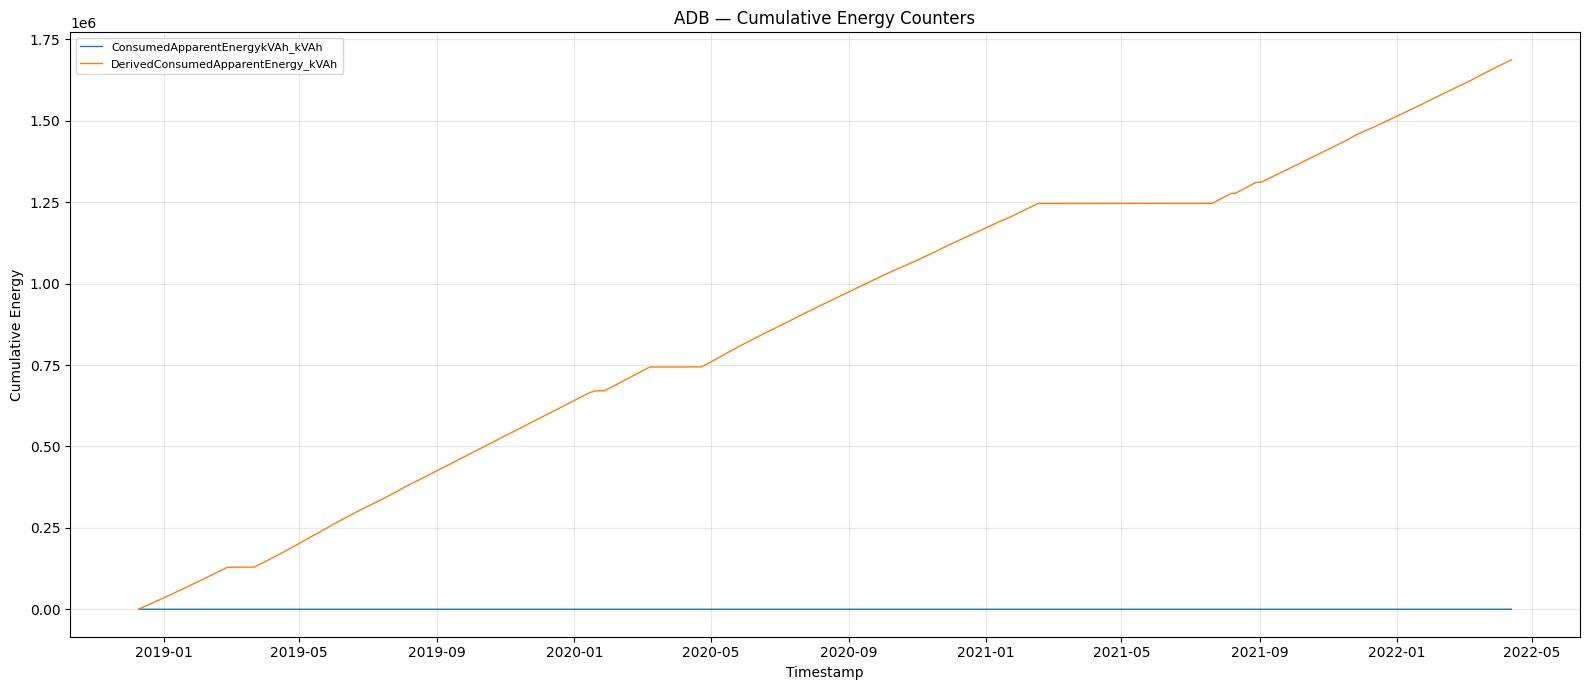

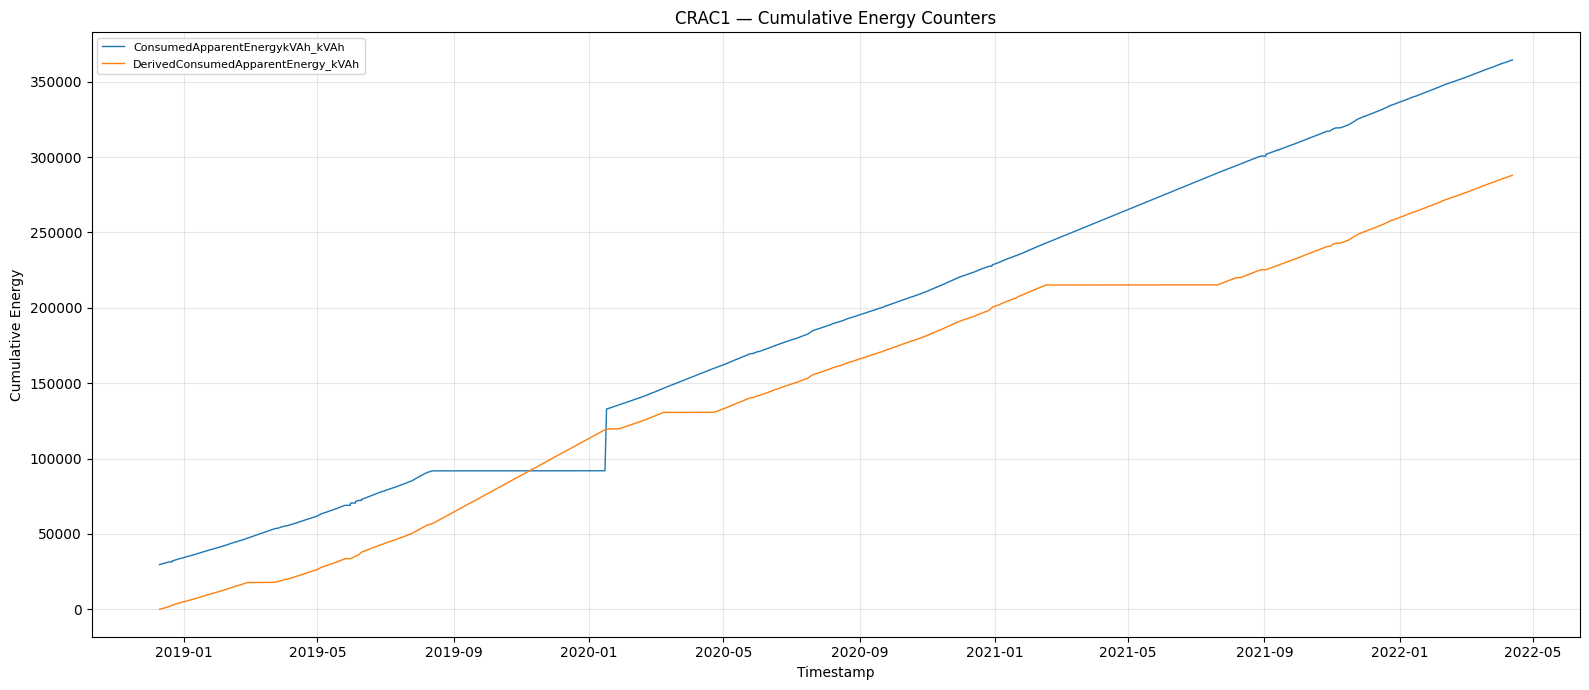

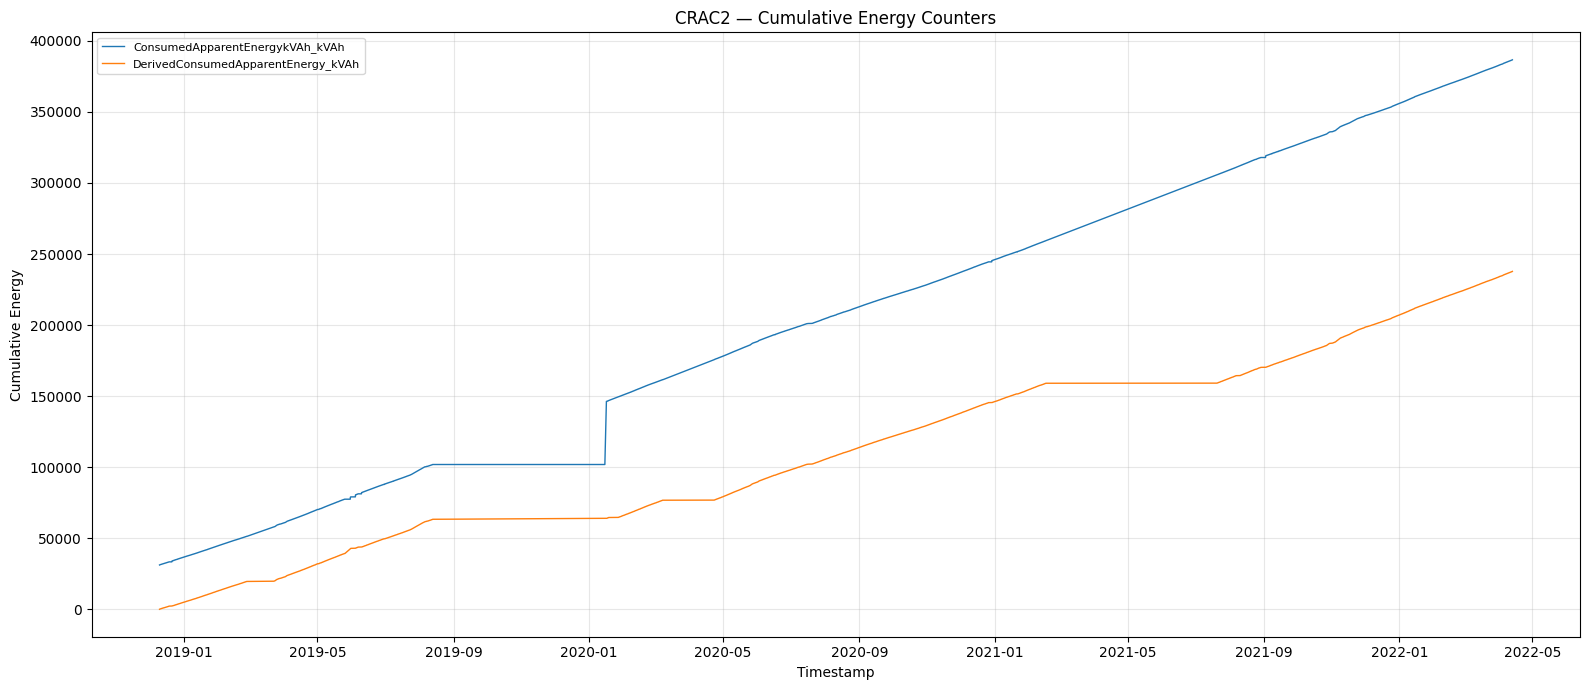

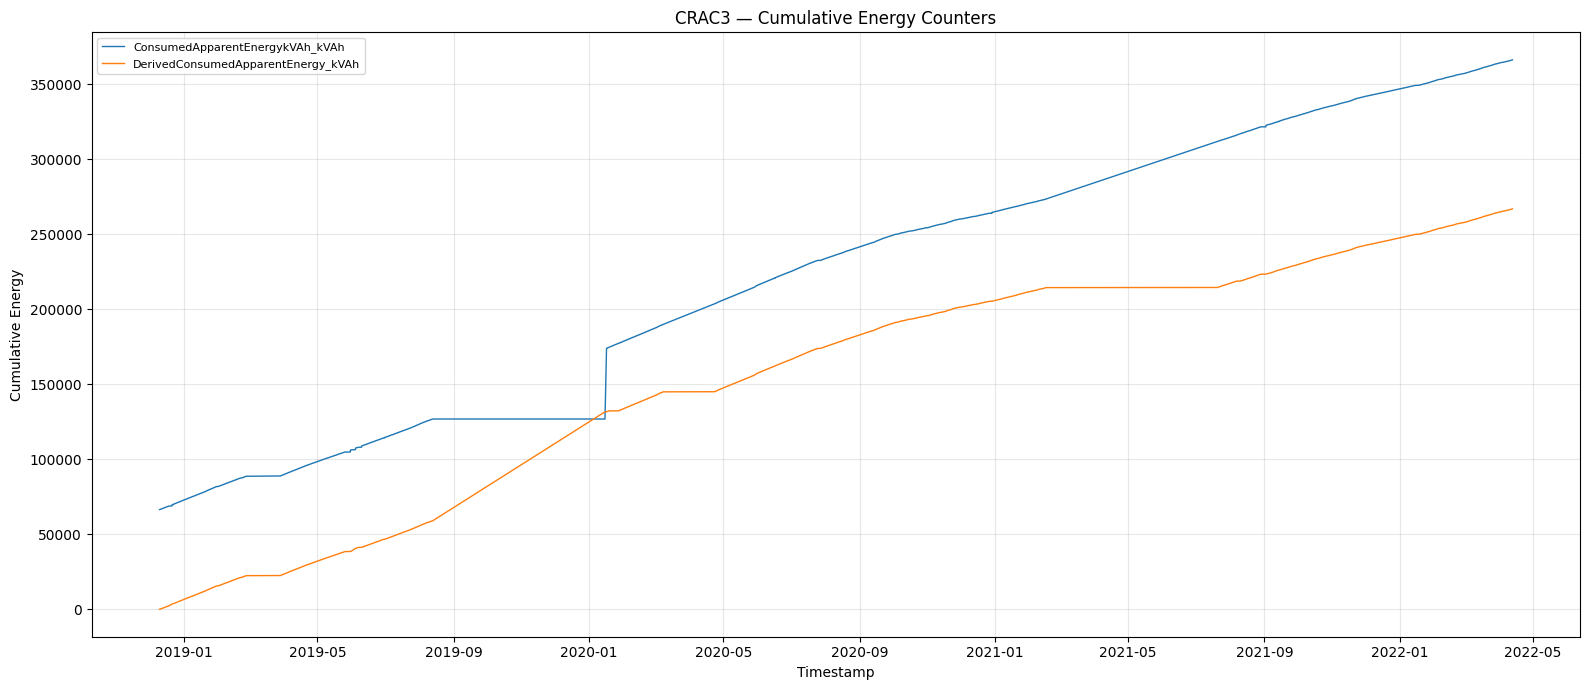

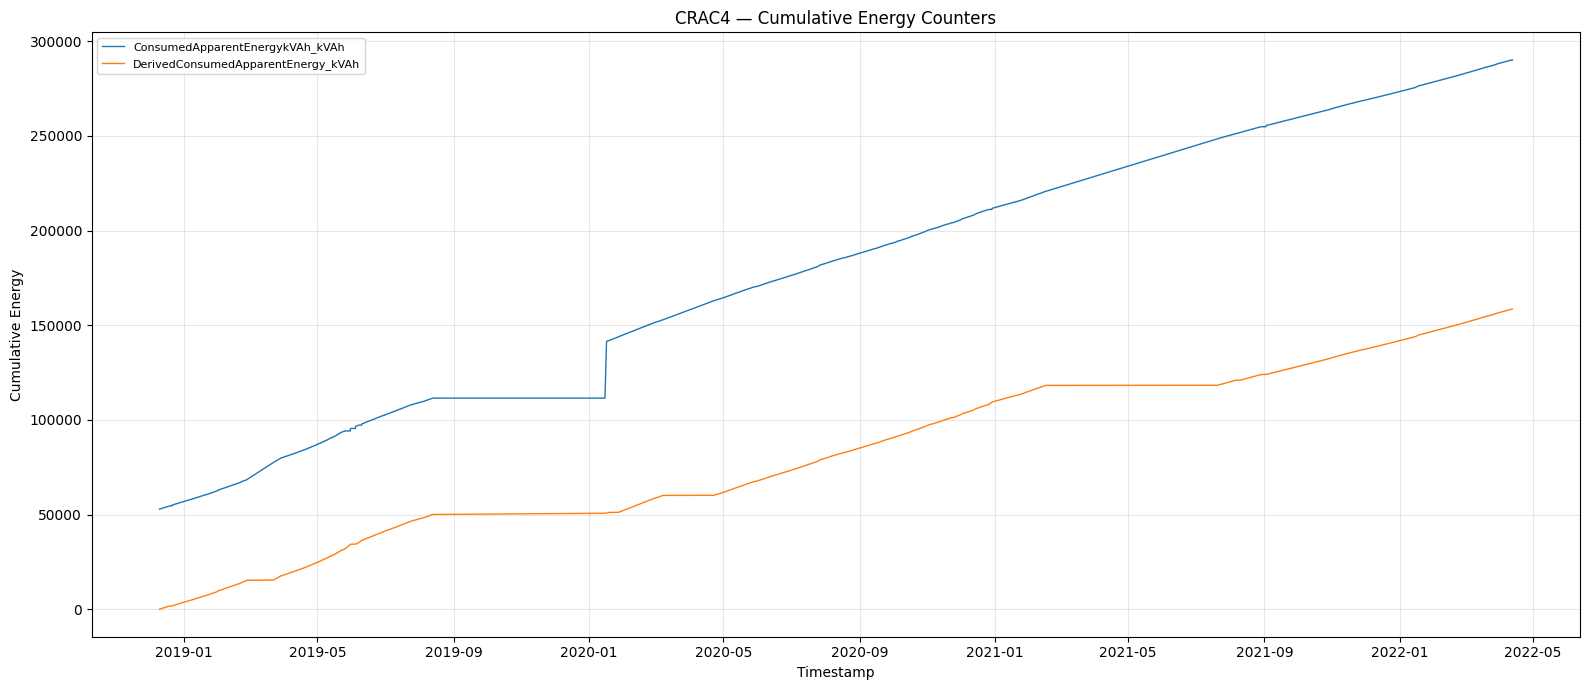

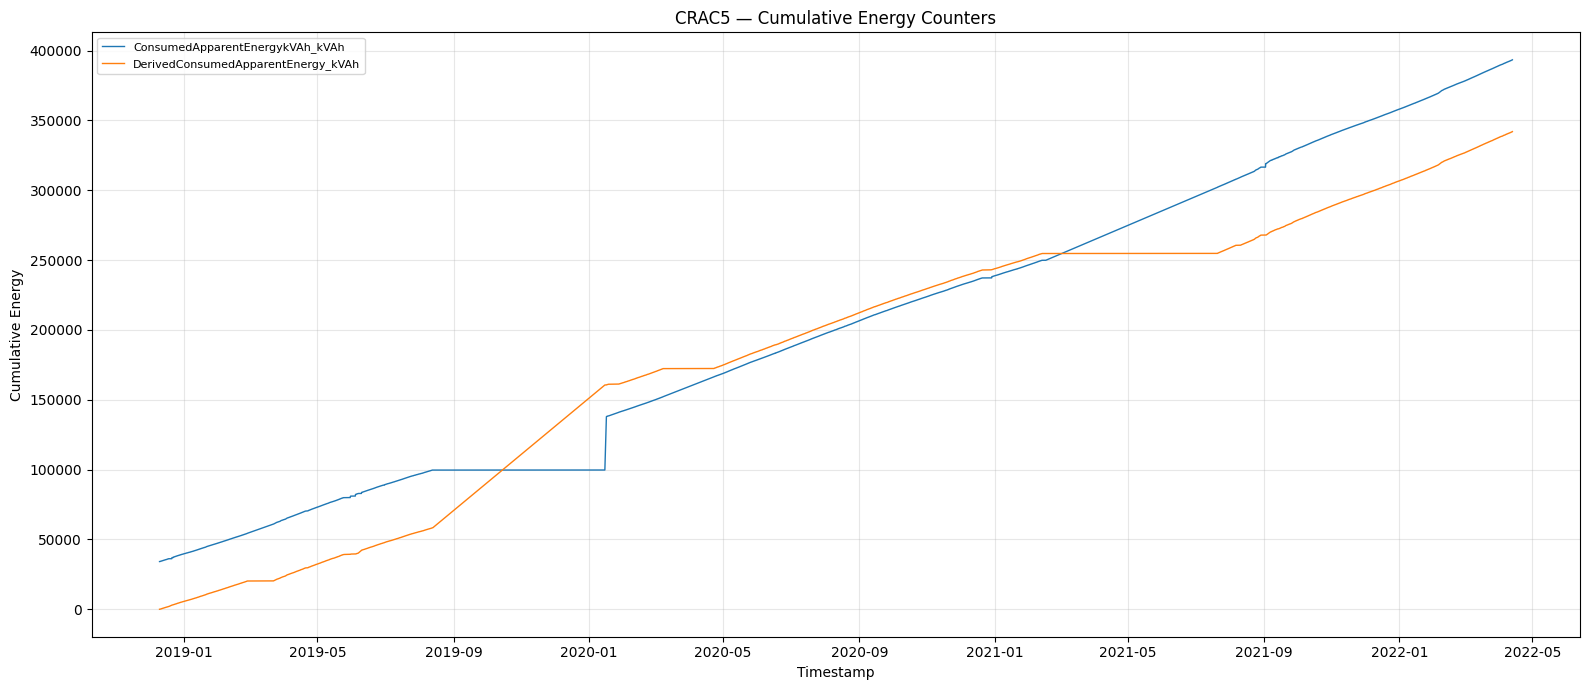

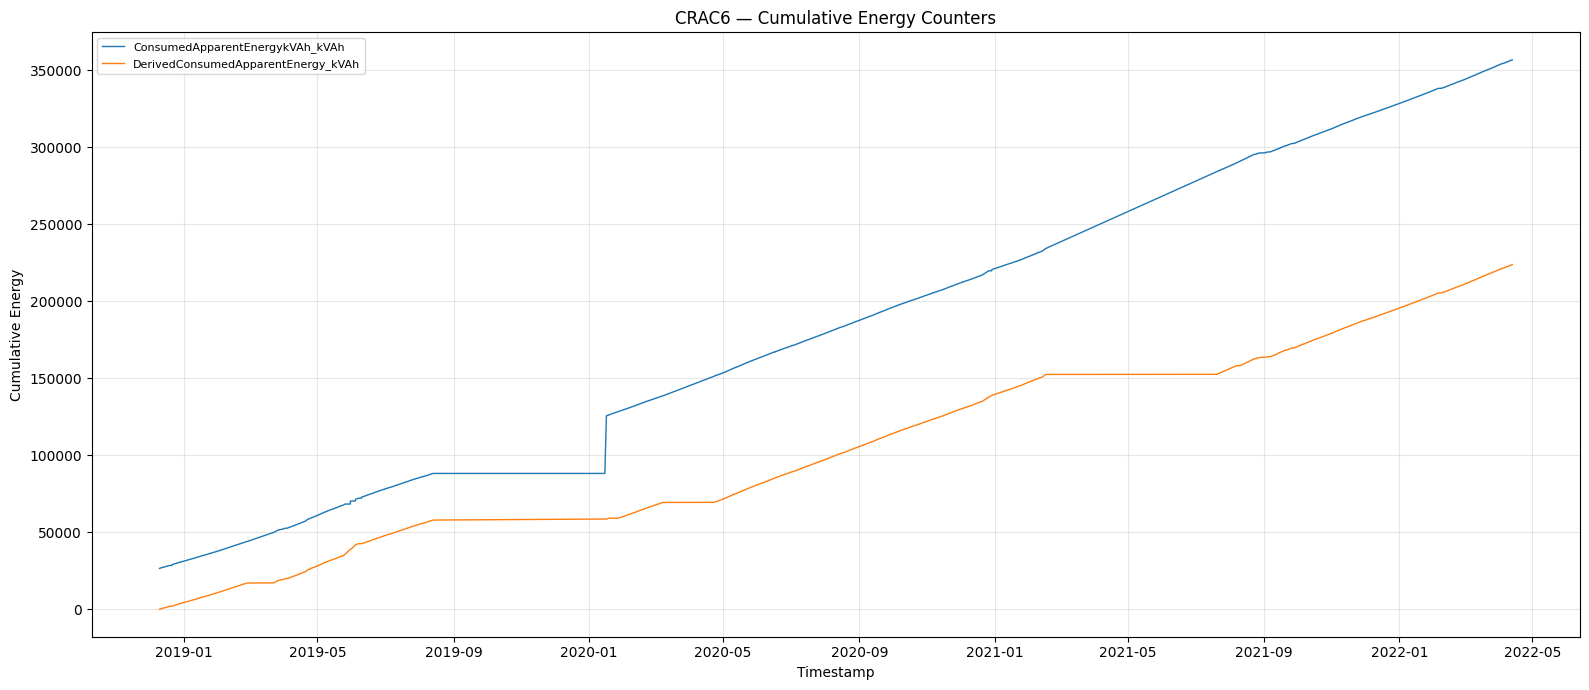

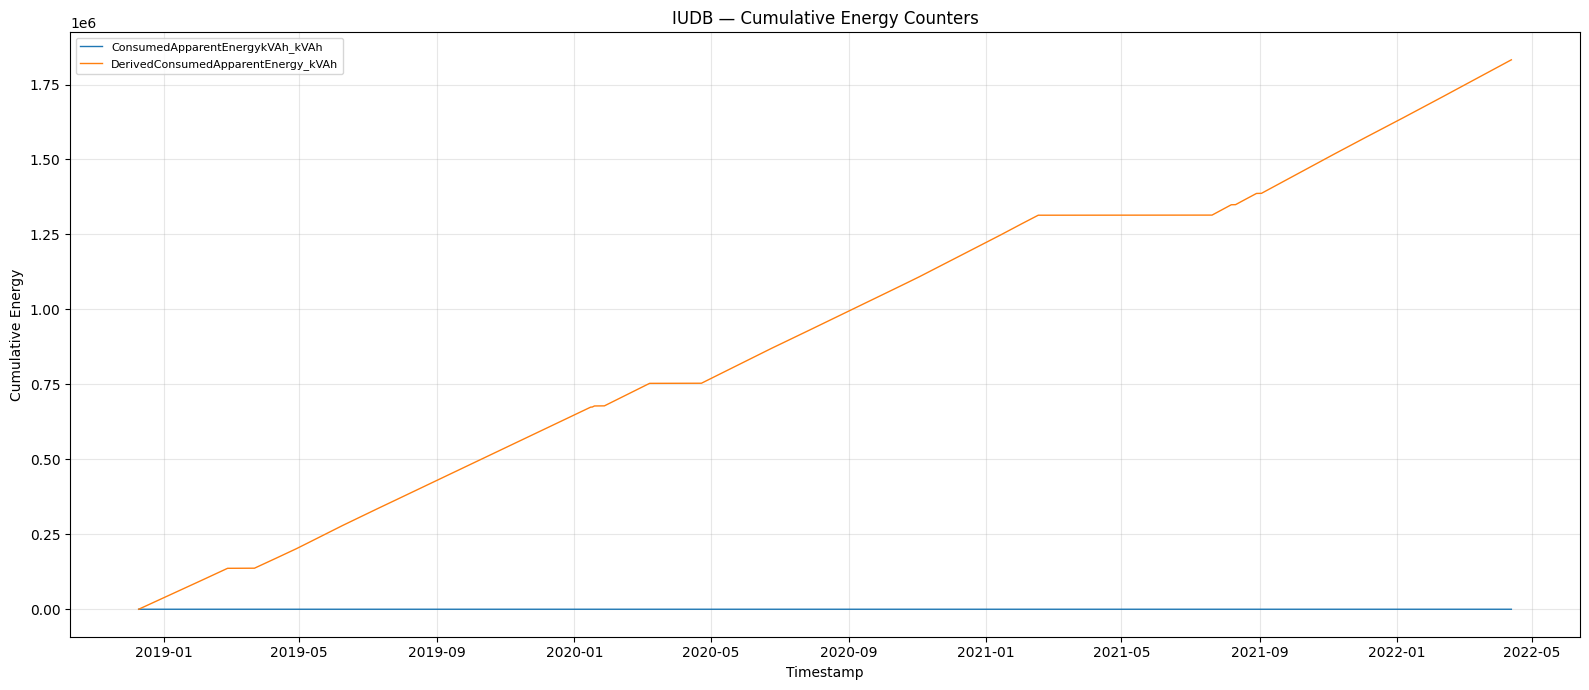

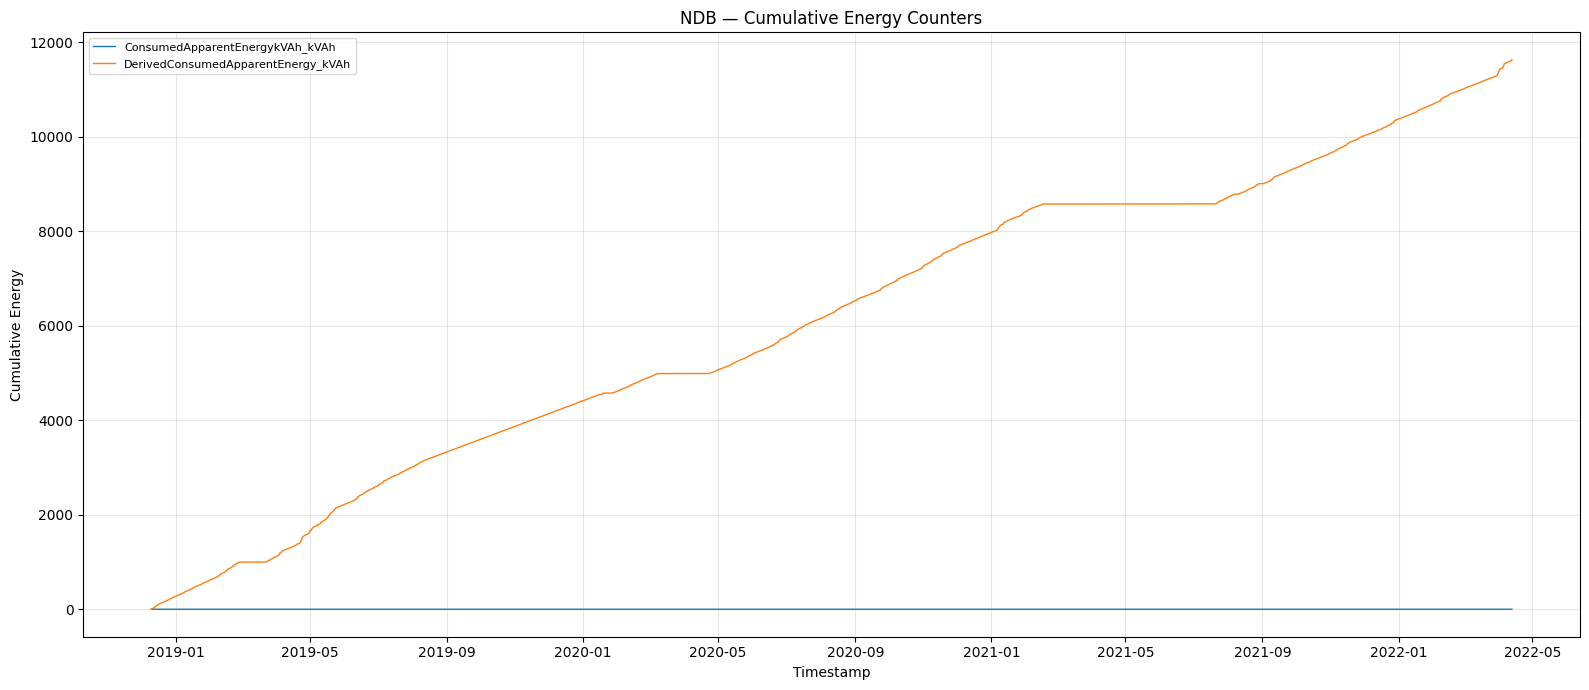

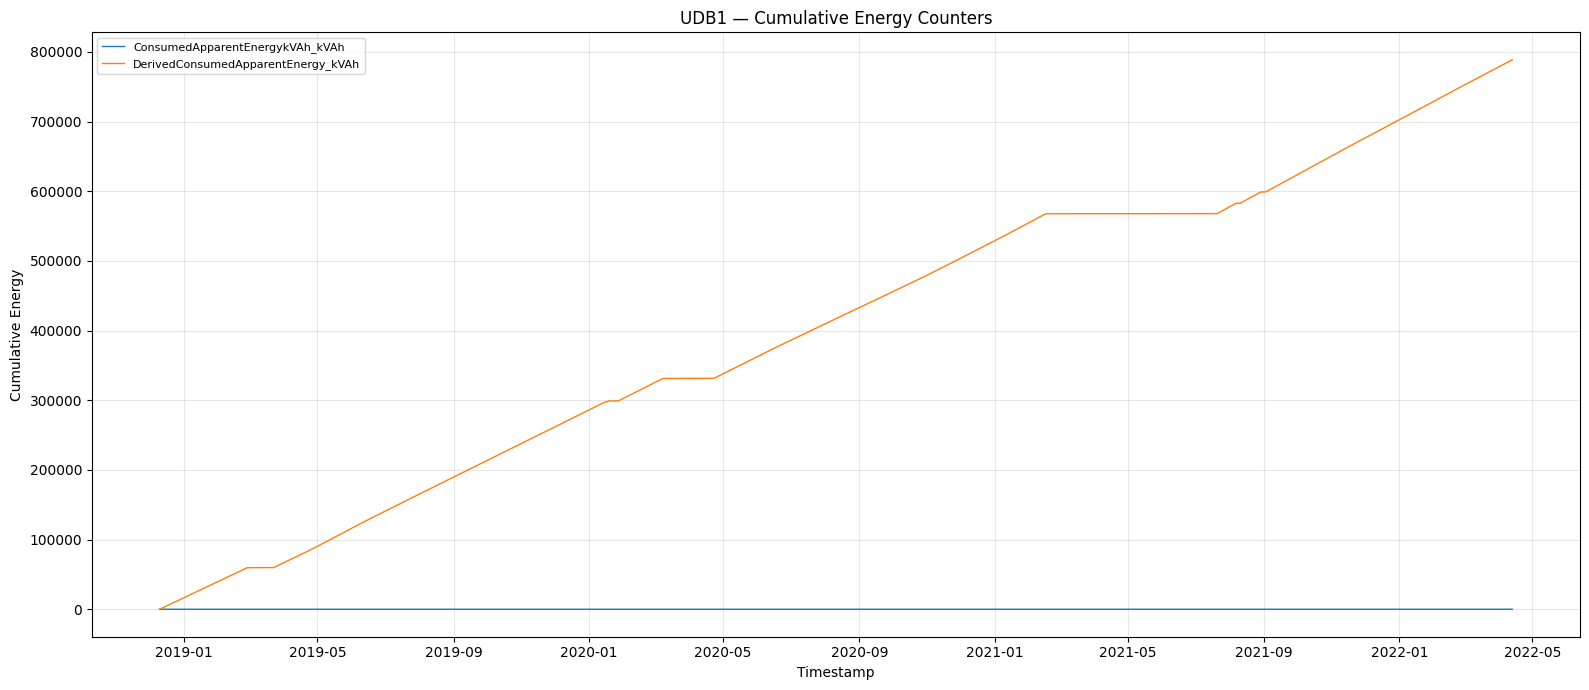

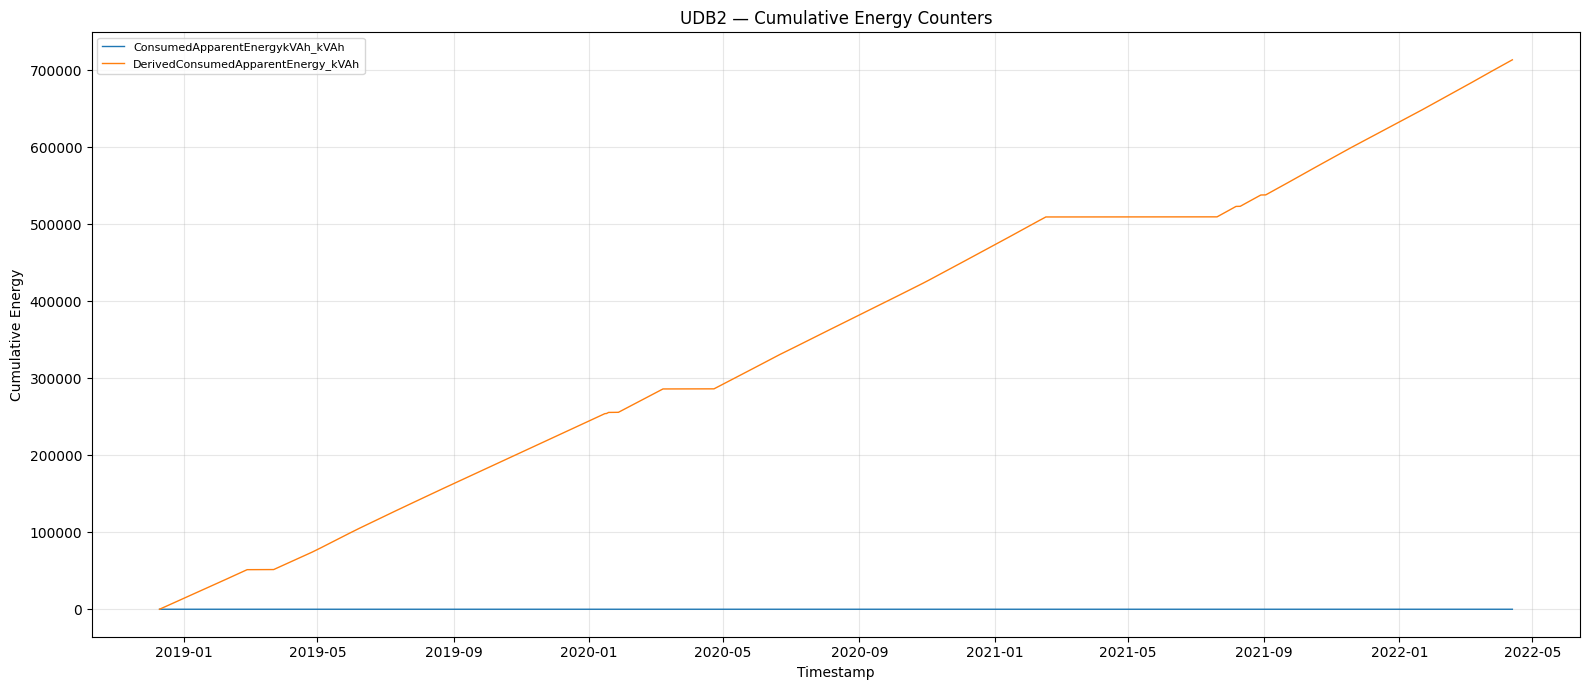

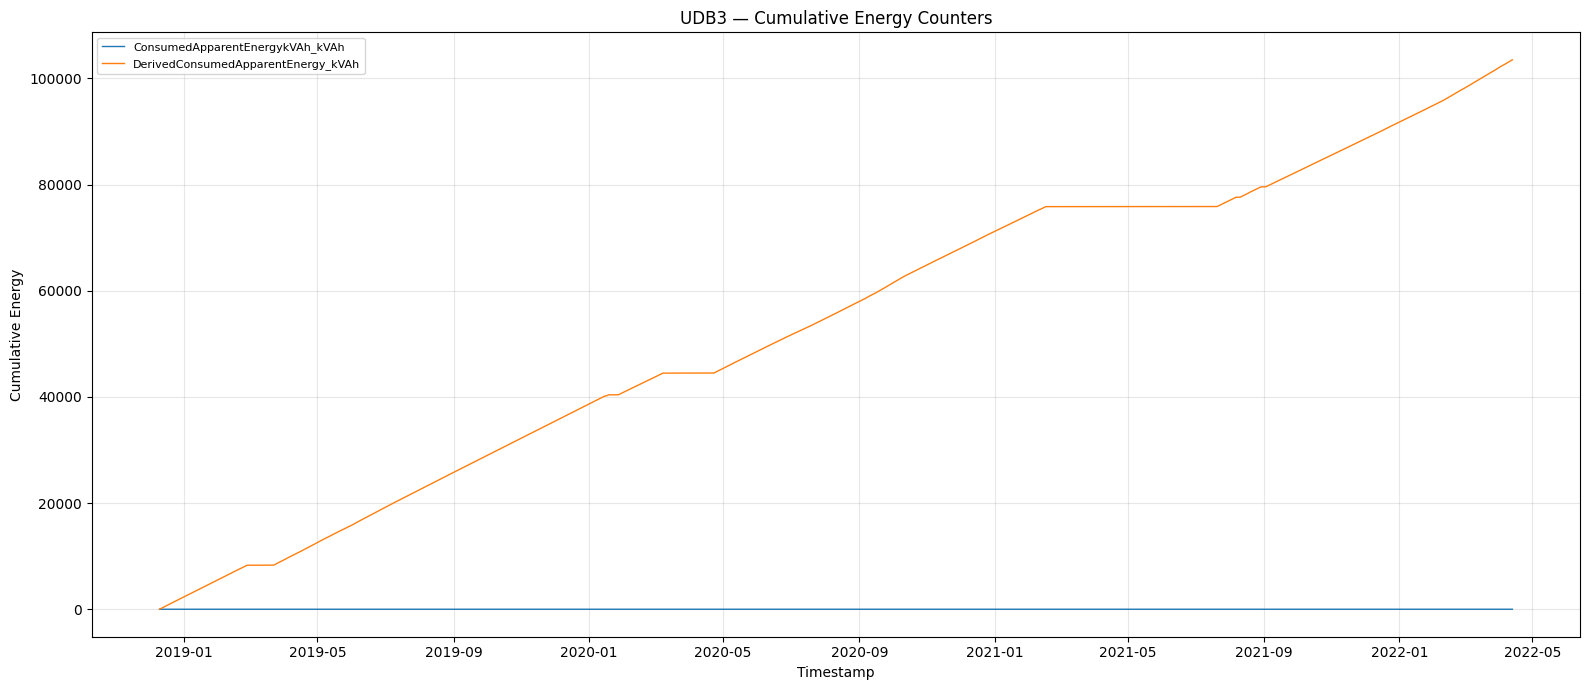

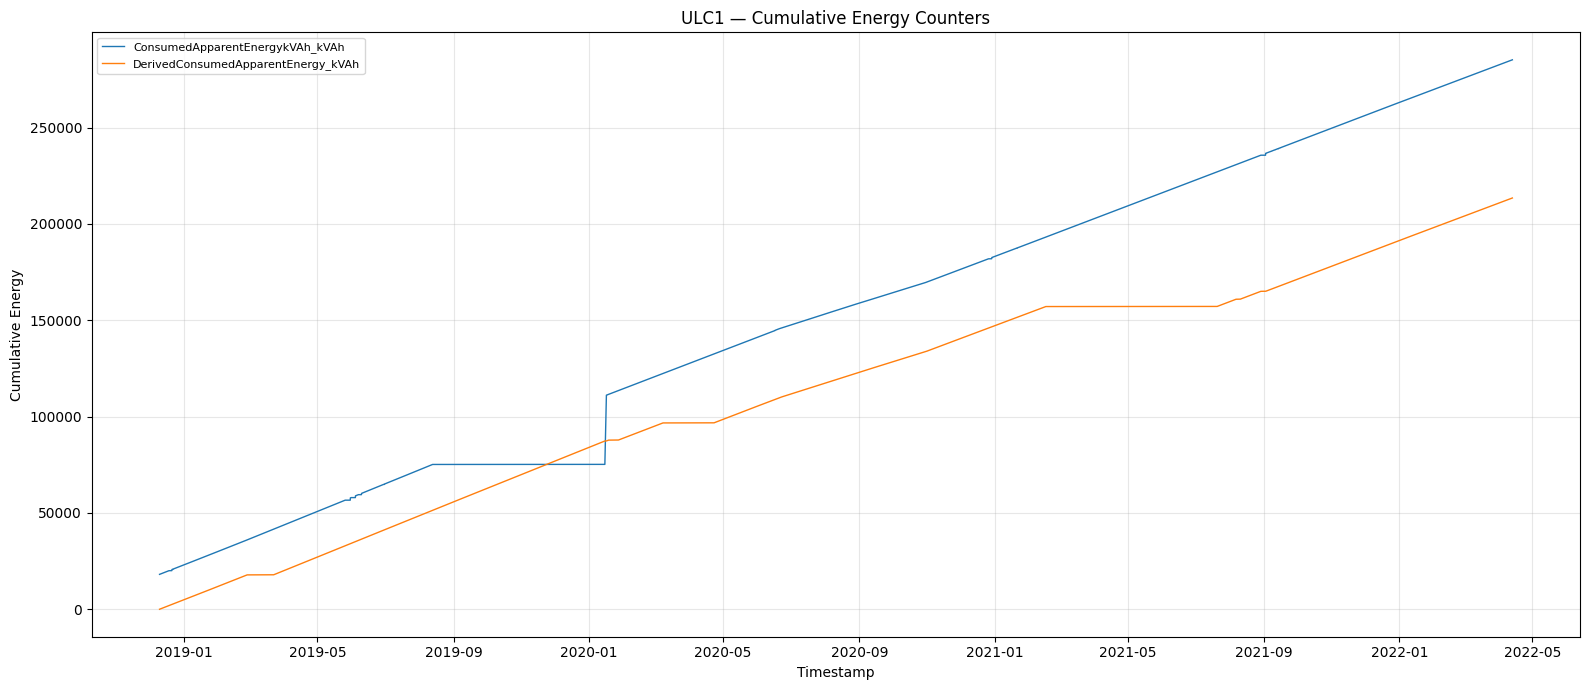

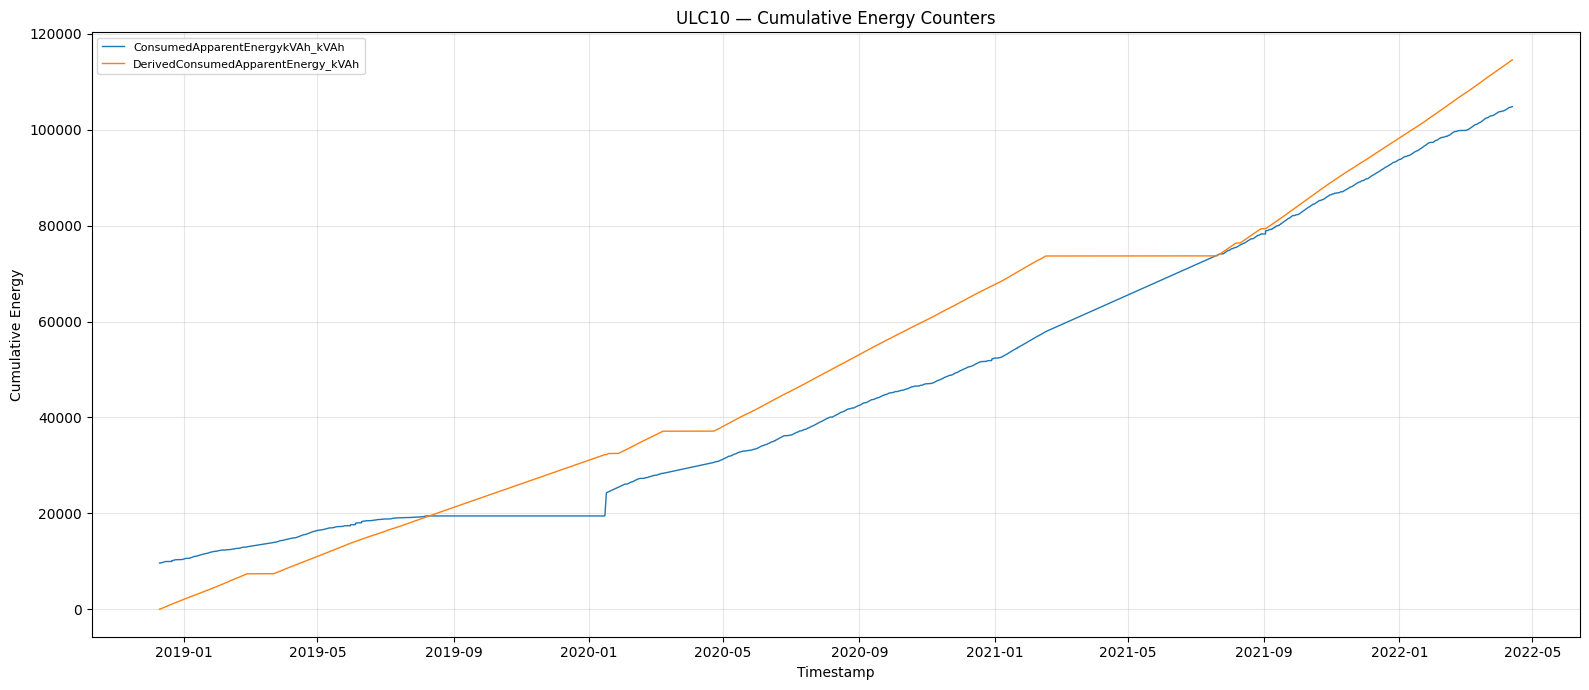

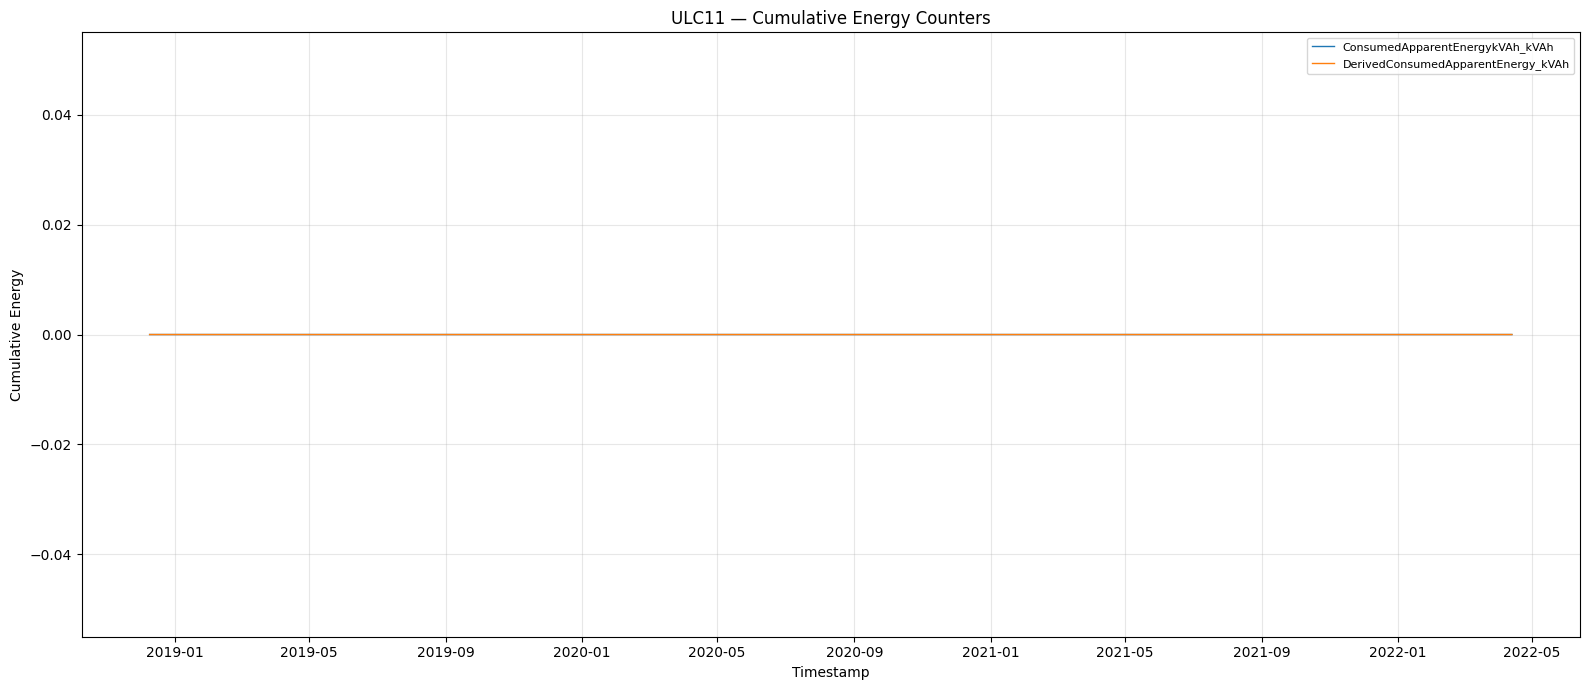

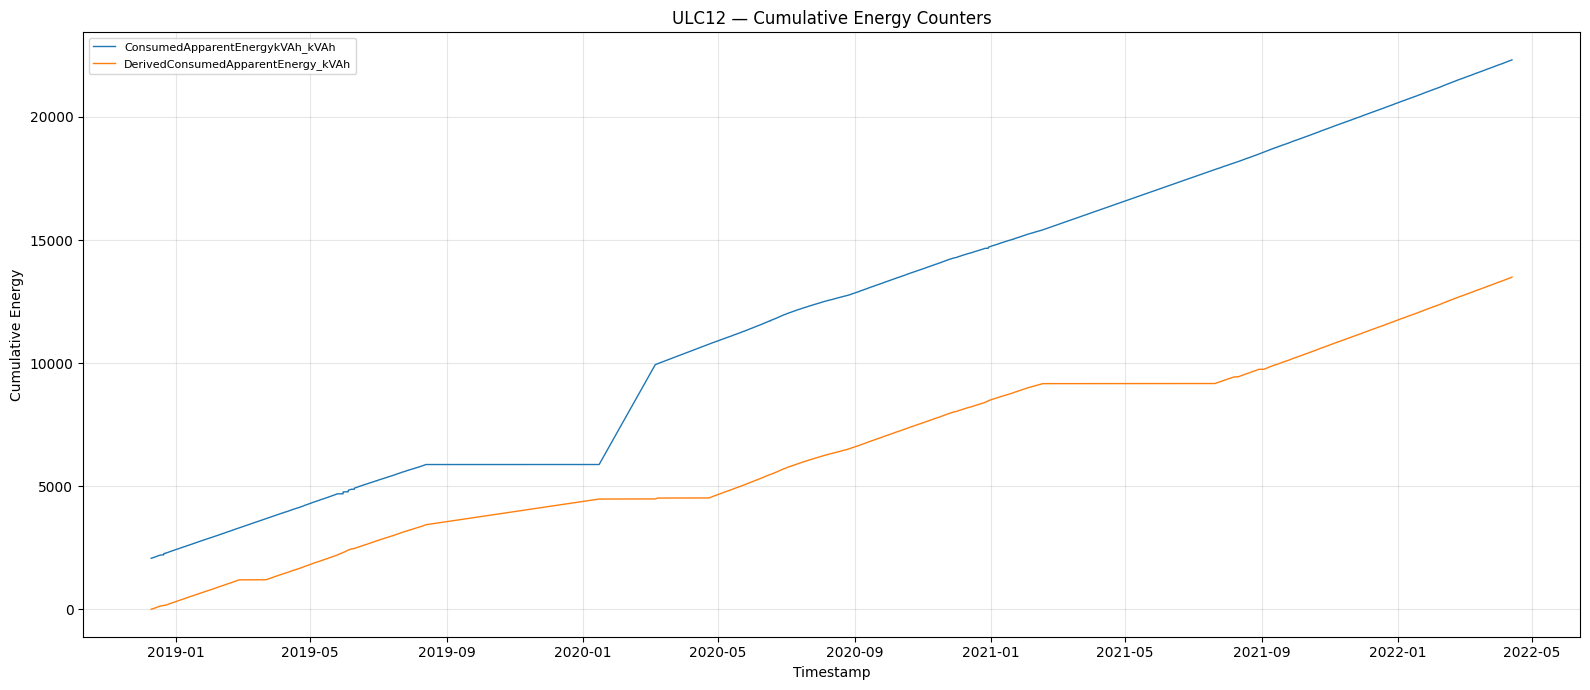

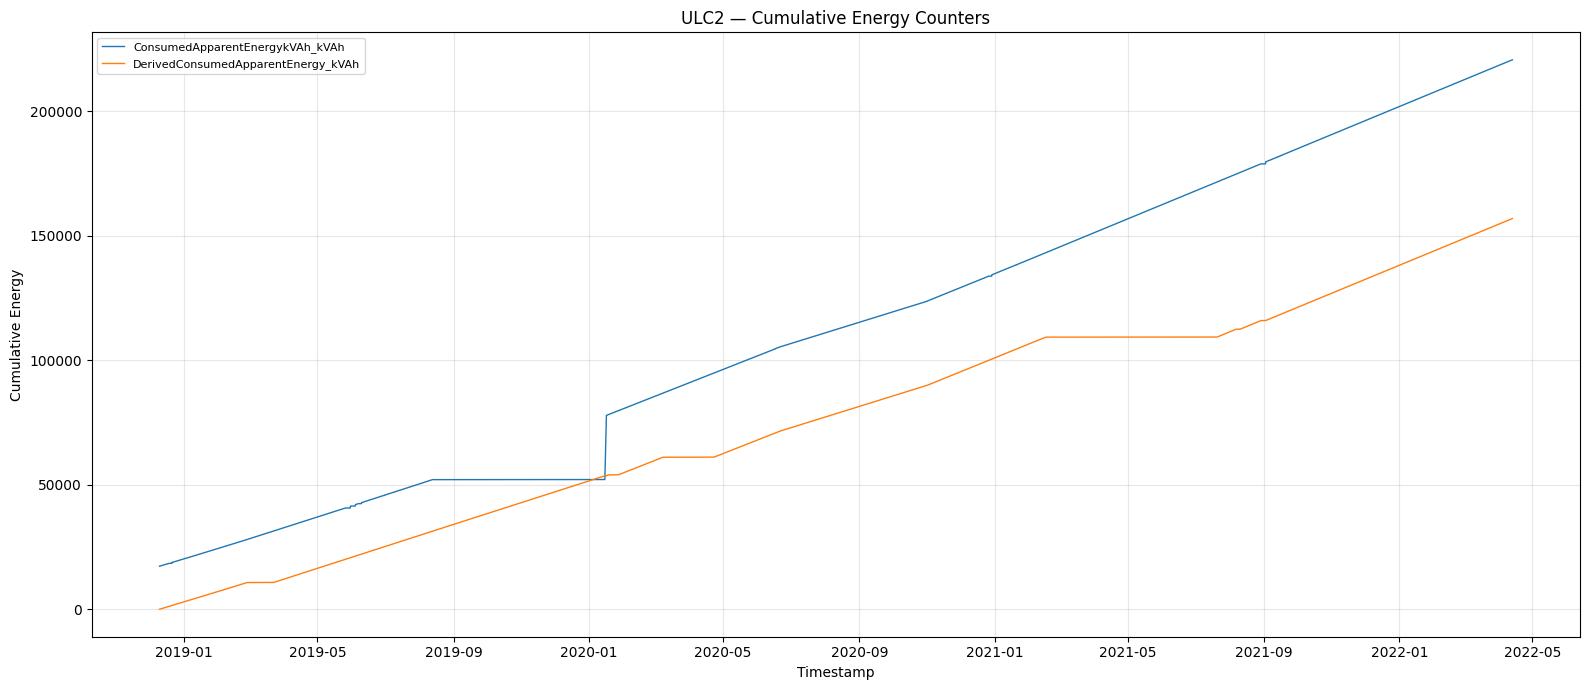

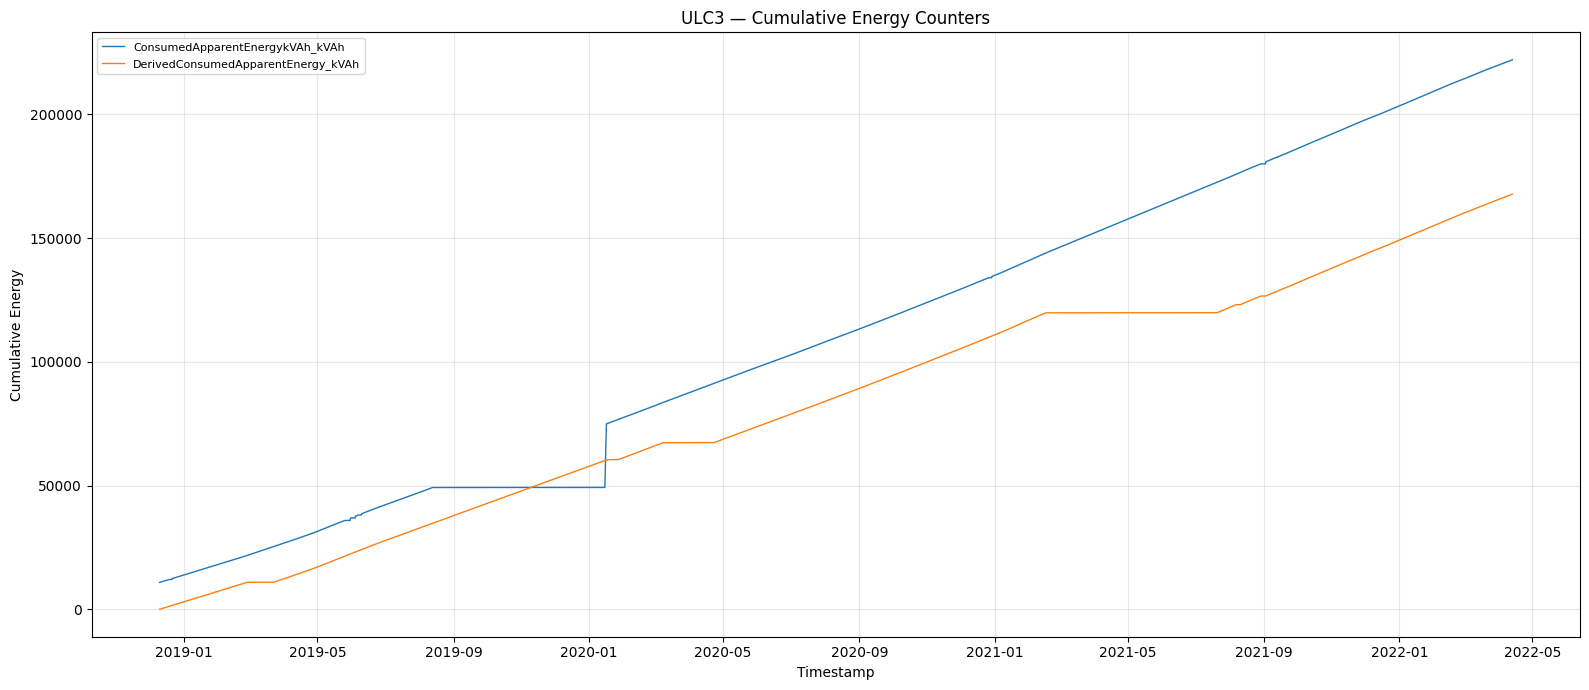

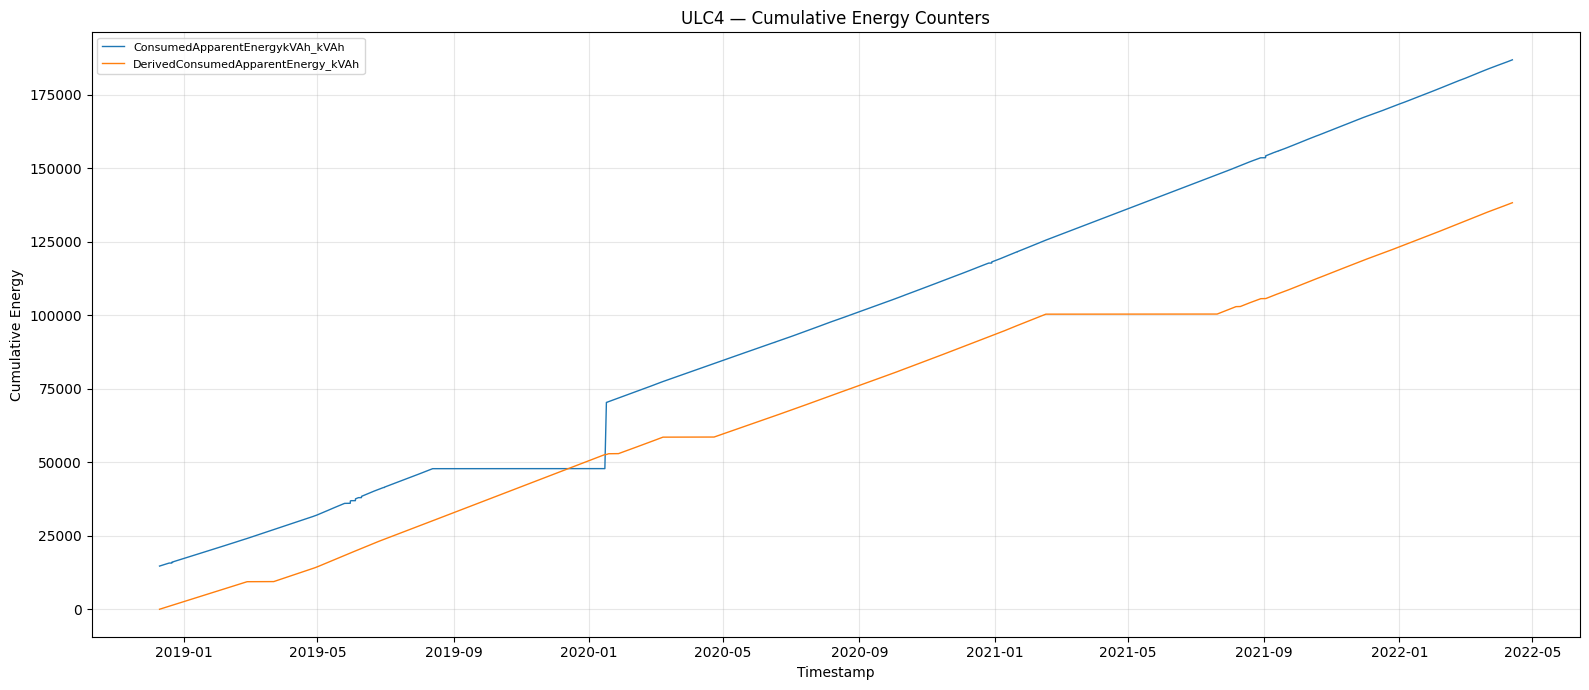

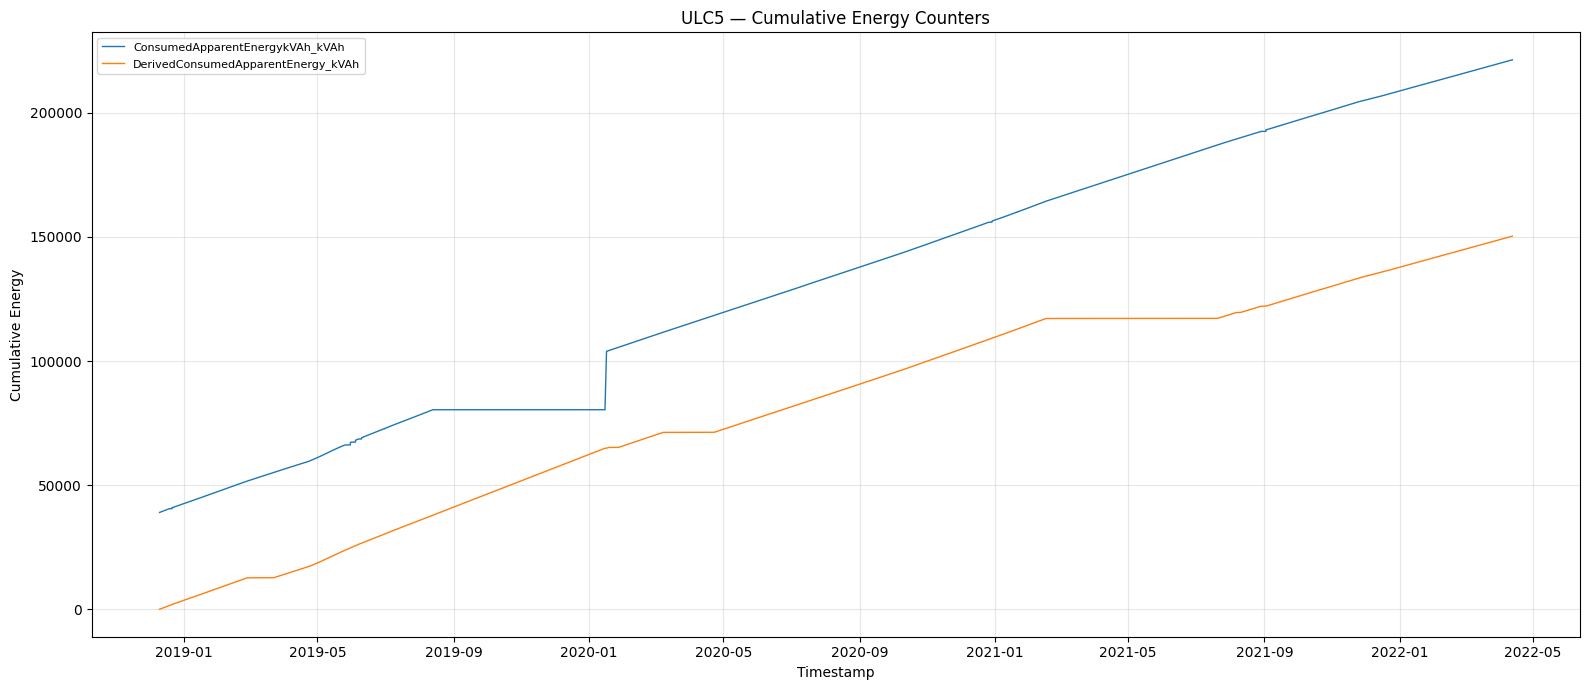

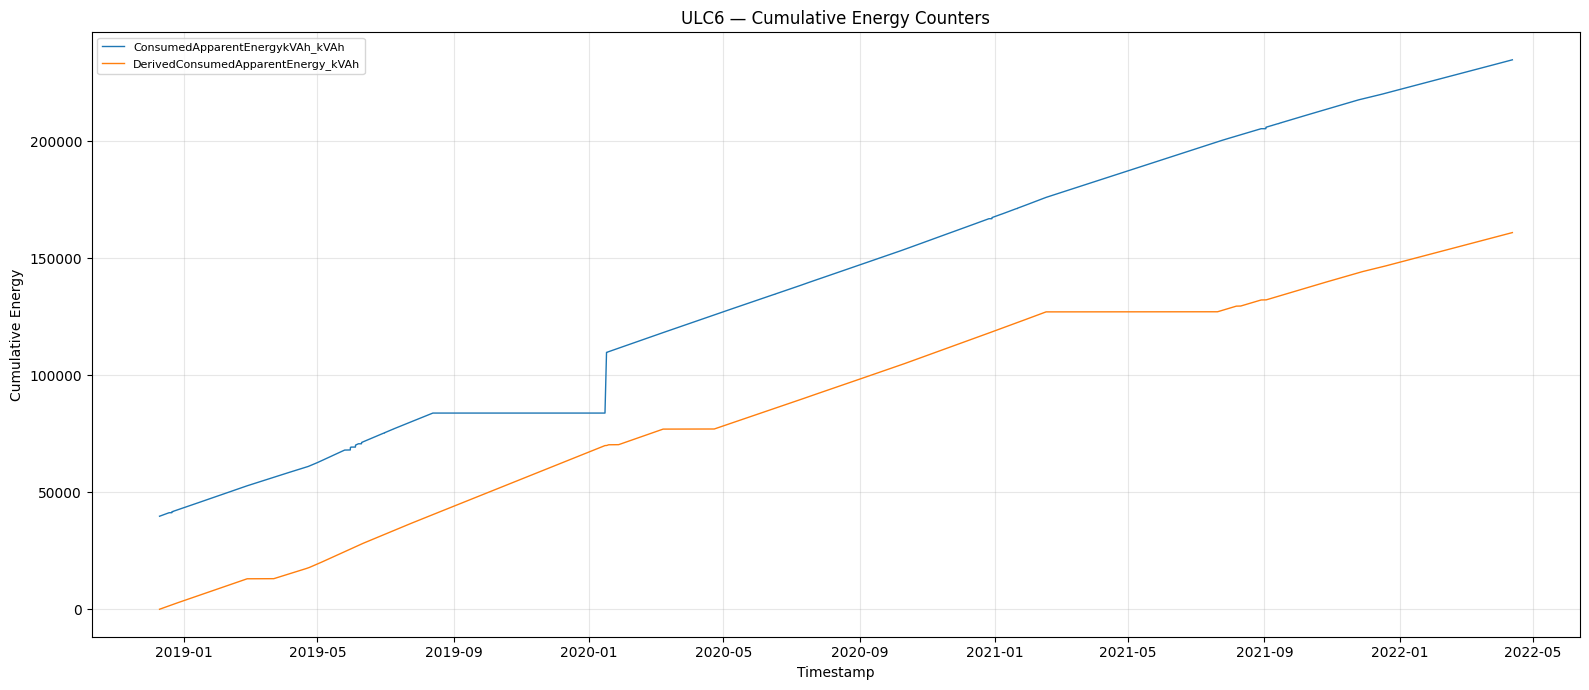

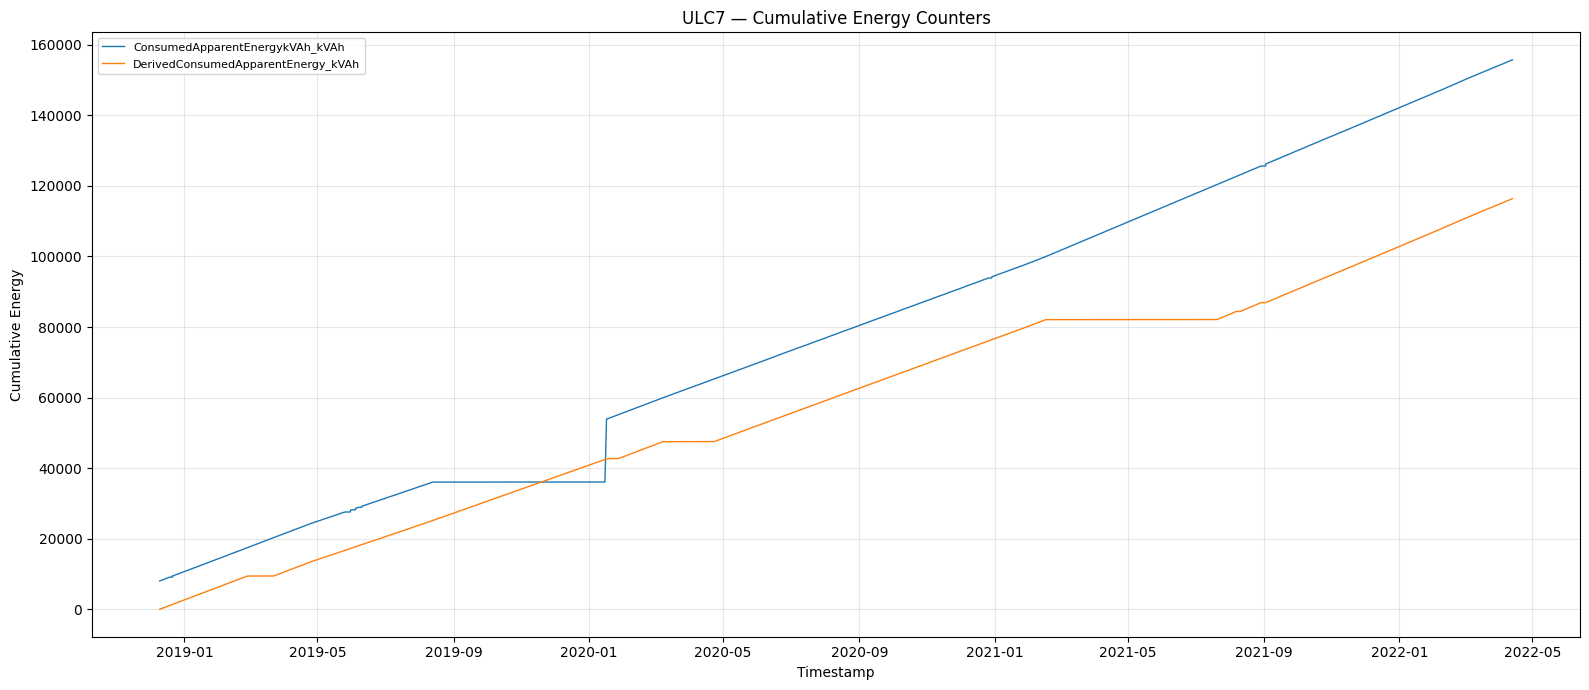

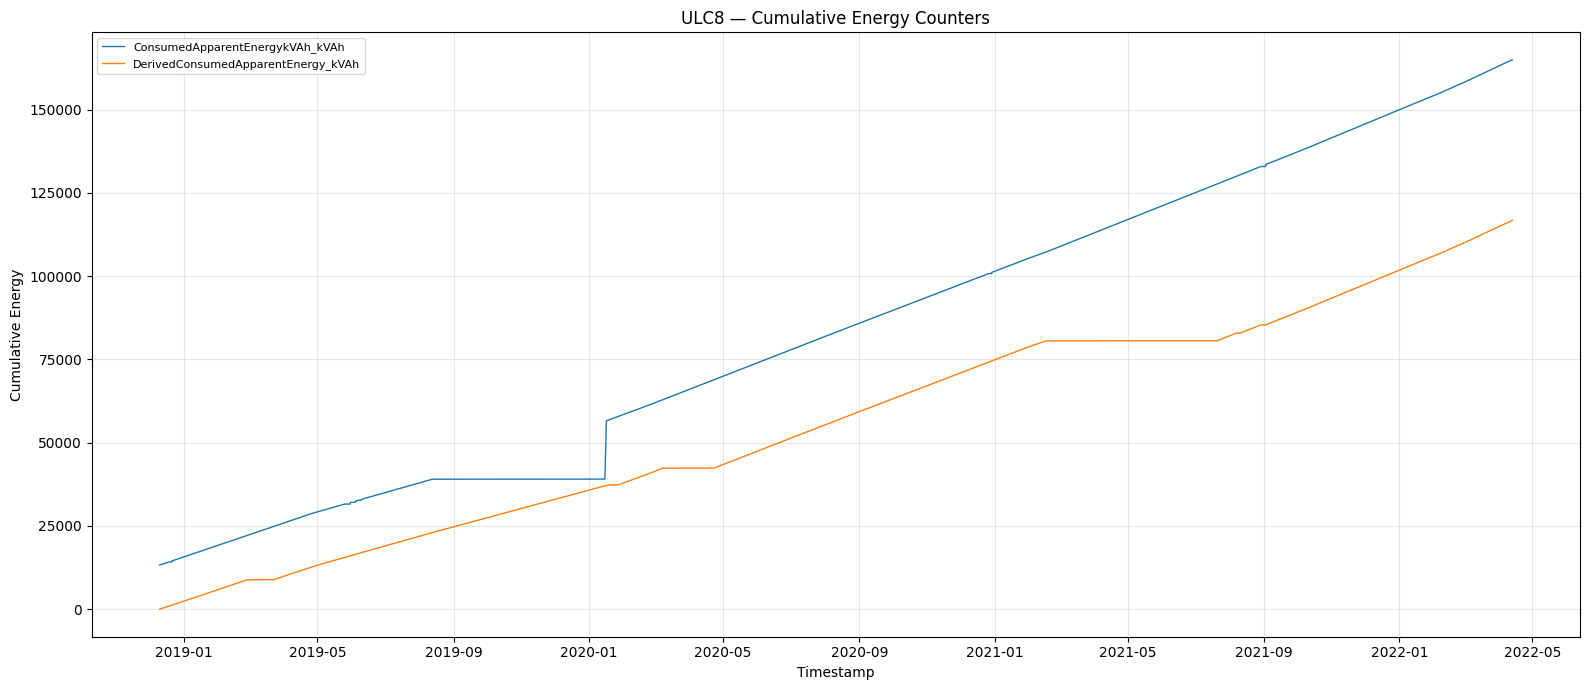

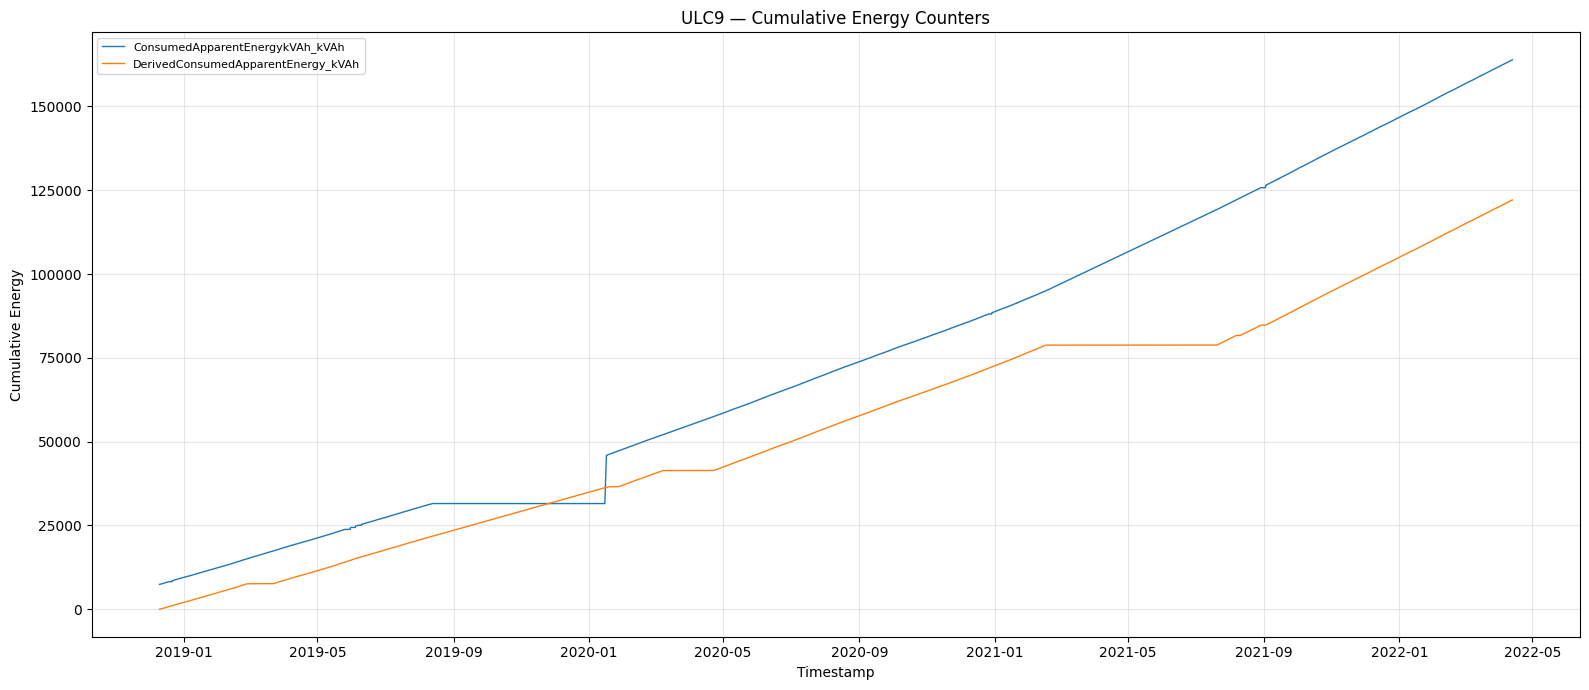

In [7]:
# =============================================================================
# IMPORTS
# =============================================================================

import matplotlib.pyplot as plt


# =============================================================================
# CUMULATIVE ENERGY COLUMNS
# =============================================================================

CUMULATIVE_ENERGY_COLUMNS = [
    # Original measured counters
    #"ConsumedActiveEnergyW_Wh",
    #"ConsumedActiveEnergykW_kWh",
    #"ConsumedApparentEnergyVAh_VAh",
    "ConsumedApparentEnergykVAh_kVAh",
    #"ConsumedCapacitiveReactiveEnergykvarhC_kvarh",
    #"ConsumedCapacitiveReactiveEnergyvarhC_varh",
    #"ConsumedInductiveReactiveEnergykvarhL_kvarh",
    #"ConsumedInductiveReactiveEnergyvarhL_varh",

    # Derived counters
    #"DerivedConsumedActiveEnergy_kWh",
    "DerivedConsumedApparentEnergy_kVAh",
    #"DerivedConsumedCapacitiveReactiveEnergy_kvarh",
]


# =============================================================================
# PLOT CUMULATIVE ENERGY COUNTERS FOR EACH DEVICE
# =============================================================================

for device, df in datasets.items():

    columns = [
        column
        for column in CUMULATIVE_ENERGY_COLUMNS
        if column in df.columns
    ]

    if not columns:
        continue

    fig, ax = plt.subplots(figsize=(16, 7))

    for column in columns:
        ax.plot(
            df.index,
            df[column],
            linewidth=1,
            label=column,
        )

    ax.set_title(f"{device} — Cumulative Energy Counters")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Cumulative Energy")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

# 4. Cos-Phi & PF Columns:

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import matplotlib.pyplot as plt


# =============================================================================
# POWER FACTOR / COS PHI COLUMNS
# =============================================================================

PF_COSPHI_COLUMNS = [
    # Original measured
    "L1PowerFactor_x100",
    #"L2PowerFactor_x100",
    #"L3PowerFactor_x100",
    #"ThreePhasePowerFactor_x100",
    #"CosPhiL1_x100",
    #"CosPhiL2_x100",
    #"CosPhiL3_x100",
    #"ThreePhaseCosPhi_x100",

    # Derived
    "DerivedL1PowerFactor_x100",
    #"DerivedL2PowerFactor_x100",
    #"DerivedL3PowerFactor_x100",
    #"DerivedThreePhasePowerFactor_x100",
    #"DerivedL1CosPhi_x100",
    #"DerivedL2CosPhi_x100",
    #"DerivedL3CosPhi_x100",
    #"DerivedThreePhaseCosPhi_x100",
]


# =============================================================================
# PLOT EACH DEVICE
# =============================================================================

for device, df in datasets.items():

    columns = [
        col for col in PF_COSPHI_COLUMNS
        if col in df.columns
    ]

    if not columns:
        continue

    fig, ax = plt.subplots(figsize=(16, 7))

    for column in columns:
        ax.plot(
            df.index,
            df[column],
            linewidth=1,
            label=column,
        )

    ax.set_title(f"{device} — Power Factor and Cos φ")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Value ×100")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

NameError: name 'datasets' is not defined